In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

### 1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

### 2. Преобразуйте признак Sex в числовой: значение F должно перейти в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x ==’M’ else (-1 if x == ’F’ else 0))

### 3. Разделите содержимое файлов на признаки и целевую переменную. В последнем столбце записана целевая переменная, в остальных — признаки.

In [2]:
df = pd.read_csv('abalone.csv')
df['Sex'] = df['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
n_range = list(range(1, 51))
all_scores = []

### 4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor) с различным числом деревьев: от 1 до 50 (random_state=1). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

### 5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это количество и будет ответом на задание.

In [3]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)
ans = None
for n in range(1, 51):
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    score = np.mean(cross_val_score(rf, X, y, cv=cv, scoring='r2'))
    all_scores.append(score) 
    if score > 0.52:
        ans = n
        break

In [4]:
print(f"Ответ: {ans}")

Ответ: 21


### 6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

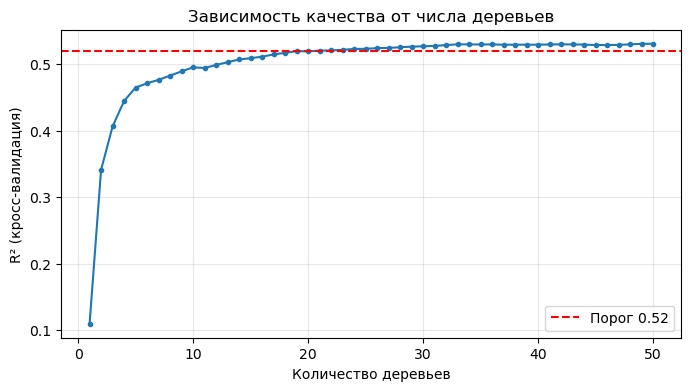

In [5]:
all_scores = []
n_range = list(range(1, 51))

for n in n_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    score = np.mean(cross_val_score(rf, X, y, cv=cv, scoring='r2'))
    all_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(n_range, all_scores, marker='o', markersize=3)
plt.axhline(y=0.52, color='r', linestyle='--', label='Порог 0.52')
plt.xlabel('Количество деревьев')
plt.ylabel('R² (кросс-валидация)')
plt.title('Зависимость качества от числа деревьев')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()